# 🏥 MediBot — Adaptive RAG Development Notebook

End-to-end notebook: PDF ingestion → Pinecone indexing → Adaptive RAG with LangGraph.


## 1. Environment Setup

In [1]:
%pwd

'c:\\Users\\ADMIN\\Desktop\\Data_Science\\Projects\\End2End-MediBot\\End2End-MediBot'

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()


True

In [3]:
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")


os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [4]:
TAVILY_API_KEY   = os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"]   = TAVILY_API_KEY

## 2. PDF Loading & Chunking

In [5]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List
from langchain_core.documents import Document

In [6]:


def load_pdf_files(data):
    """Load all PDFs from a directory."""
    loader = DirectoryLoader(
        data,
        glob="*.pdf",
        loader_cls=PyPDFLoader
    )
    return loader.load()


def filter_to_minimal_docs(docs: List[Document]) -> List[Document]:
    """Strip metadata down to just 'source' to keep Pinecone payloads lean."""
    return [
        Document(
            page_content=doc.page_content,
            metadata={"source": doc.metadata.get("source")}
        )
        for doc in docs
    ]


def text_split(docs: List[Document]) -> List[Document]:
    """Split documents into 500-token chunks with 20-token overlap."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=20,
    )
    return splitter.split_documents(docs)


print("✅ Document utility functions defined")

✅ Document utility functions defined


In [7]:
# ⚠️  Run this only if your 'data/' folder has PDFs to ingest.
# Skip to Section 3 if your Pinecone index is already populated.

extracted_docs = load_pdf_files("data")
print(f"Loaded {len(extracted_docs)} pages")

Loaded 637 pages


In [8]:
minimal_docs = filter_to_minimal_docs(extracted_docs)
texts_chunk  = text_split(minimal_docs)
print(f"Total chunks: {len(texts_chunk)}")
texts_chunk[0]  # preview first chunk

Total chunks: 5859


Document(metadata={'source': 'data\\Medical_book.pdf'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION')

## 3. Embeddings & Pinecone Indexing

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings

def download_embeddings():
    """Load sentence-transformers/all-MiniLM-L6-v2 (384-dim)."""
    return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

embeddings = download_embeddings()

# Quick sanity check
vector = embeddings.embed_query("Hello world")
print(f"✅ Embeddings loaded — vector dim: {len(vector)}")

c:\ProgramData\anaconda3\envs\medibot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Embeddings loaded — vector dim: 384


In [10]:
from pinecone import Pinecone, ServerlessSpec

pc         = Pinecone(api_key=PINECONE_API_KEY)
index_name = "medibot"

if index_name not in [idx.name for idx in pc.list_indexes()]:
    pc.create_index(
        name      = index_name,
        dimension = 384,
        metric    = "cosine",
        spec      = ServerlessSpec(cloud="aws", region="us-east-1")
    )
    print(f"✅ Created Pinecone index: '{index_name}'")
else:
    print(f"✅ Index '{index_name}' already exists")

index = pc.Index(index_name)
index.describe_index_stats()

✅ Created Pinecone index: 'medibot'


{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}

In [12]:
from langchain_pinecone import PineconeVectorStore

# ── Option A: Upsert new documents (run once after PDF ingestion) ──
# Uncomment the block below only when you want to (re)index documents.

docsearch = PineconeVectorStore.from_documents(
     documents  = texts_chunk,
     embedding  = embeddings,
     index_name = index_name
 )

print("✅ Documents upserted into Pinecone")


✅ Documents upserted into Pinecone


In [13]:
# ── Option B: Load existing index (default — use this for every run) ──
docsearch = PineconeVectorStore.from_existing_index(
    index_name = index_name,
    embedding  = embeddings
)

retriever = docsearch.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# Quick test
test_docs = retriever.invoke("What is Acne?")
print(f"✅ Retriever ready — test query returned {len(test_docs)} docs")
test_docs[0]

✅ Retriever ready — test query returned 3 docs


Document(metadata={'source': 'data\\Medical_book.pdf'}, page_content='GALE ENCYCLOPEDIA OF MEDICINE 226\nAcne\nGEM - 0001 to 0432 - A  10/22/03 1:41 PM  Page 26')

## 4. Adaptive RAG Components

Each component below is an independent LangChain chain built on Groq.
They are later wired together into a LangGraph state machine.

In [50]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import Literal

# Shared LLM — llama3-70b on Groq
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
print("✅ Groq LLM ready")

✅ Groq LLM ready


In [51]:
llm.invoke("Hello world")

AIMessage(content='Hello! How can I assist you today?', response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 73, 'total_tokens': 111, 'completion_time': 0.080559133, 'prompt_time': 0.002806548, 'queue_time': 0.042605617, 'total_time': 0.083365681, 'completion_tokens_details': {'reasoning_tokens': 20}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'finish_reason': 'stop', 'logprobs': None}, id='run-b1b6b583-3a93-4296-b096-559c4f0b2e08-0', usage_metadata={'input_tokens': 73, 'output_tokens': 38, 'total_tokens': 111})

### 4a. Router
Decides whether to answer from the **Pinecone vectorstore** or fall back to **web search**.

In [52]:
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Literal["vectorstore", "web_search"] = Field(
        description="'vectorstore' for medical KB queries, 'web_search' for recent/unknown topics."
    )

router_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are an expert at routing a user question to the right datasource.

The vectorstore contains medical knowledge: diseases, symptoms, treatments, medications,
anatomy, pharmacology, and general health information.

Route to 'vectorstore' for medical/health questions answerable from a medical reference.
Route to 'web_search' for recent medical news, non-medical questions, or specific clinics/doctors.

Return ONLY the routing decision."""),
    ("human", "{question}"),
])

question_router = router_prompt | llm.with_structured_output(RouteQuery)

# Test
print(question_router.invoke({"question": "What are the symptoms of diabetes?"}))
print(question_router.invoke({"question": "Latest FDA drug approvals 2025?"}))

{'datasource': 'vectorstore'}
{'datasource': 'web_search'}


### 4b. Retrieval Grader
Filters out irrelevant retrieved documents before passing them to the generator.

In [53]:
class GradeDocuments(BaseModel):
    """Binary relevance score for a retrieved document."""
    binary_score: str = Field(description="'yes' if relevant, 'no' if not.")

grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader assessing the relevance of a retrieved medical document to a user question.
If the document contains keywords or semantic meaning related to the question, grade it as relevant.
This is not a strict test — just filter clearly irrelevant retrievals.
Respond with 'yes' or 'no'."""),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

retrieval_grader = grade_prompt | llm.with_structured_output(GradeDocuments)

# Test
question  = "What is Acne?"
docs      = retriever.invoke(question)
doc_txt   = docs[0].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

{'binary_score': 'yes'}


### 4c. RAG Generation Chain

In [54]:
system_prompt = (
    "You are a Medical assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, say that you don't know. "
    "Use three sentences maximum and keep the answer concise."
    "\n\n{context}"
)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

rag_chain = rag_prompt | llm | StrOutputParser()

# Test
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Acne is a common skin disease, medically termed acne vulgaris, that produces pimples primarily on the face, chest, and back. It occurs when skin pores become clogged with oil, dead skin cells, and bacteria, leading to inflammation of the sebaceous glands. It is the most prevalent skin disorder, affecting millions of people.


### 4d. Hallucination Grader
Checks whether the generated answer is grounded in the retrieved documents.

In [55]:
class GradeHallucinations(BaseModel):
    """Binary score — is the generation grounded in the facts?"""
    binary_score: str = Field(description="'yes' if grounded, 'no' if hallucinated.")

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader checking whether an LLM medical answer is grounded in the source documents.
'yes' = answer is supported. 'no' = answer contains hallucinations. Be strict — patient safety matters."""),
    ("human", "Source documents:\n\n{documents}\n\nLLM answer: {generation}"),
])

hallucination_grader = hallucination_prompt | llm.with_structured_output(GradeHallucinations)

print(hallucination_grader.invoke({"documents": docs, "generation": generation}))

{'binary_score': 'yes'}


### 4e. Answer Grader
Checks whether the answer actually resolves the user's question.

In [56]:
class GradeAnswer(BaseModel):
    """Binary score — does the answer resolve the question?"""
    binary_score: str = Field(description="'yes' if resolved, 'no' if not.")

answer_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader assessing whether a medical answer resolves the user's question.
'yes' = directly addresses the question. 'no' = off-topic, incomplete, or missing."""),
    ("human", "User question:\n\n{question}\n\nLLM answer: {generation}"),
])

answer_grader = answer_prompt | llm.with_structured_output(GradeAnswer)

print(answer_grader.invoke({"question": question, "generation": generation}))

{'binary_score': 'yes'}


### 4f. Query Rewriter
Rewrites the question for better vectorstore retrieval when initial docs are irrelevant.

In [57]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a query optimizer for a medical vectorstore retrieval system.
Rewrite the input question into a cleaner, more precise version that retrieves better results.
Focus on the core medical concept. Remove conversational filler.
Return ONLY the improved question."""),
    ("human", "Original question:\n\n{question}\n\nImproved question:"),
])

question_rewriter = rewrite_prompt | llm | StrOutputParser()

print(question_rewriter.invoke({"question": "my head hurts a lot what could be wrong?"}))

What are the possible causes of a severe headache?


### 4g. Web Search Tool (Tavily fallback)

In [58]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

# Test
results = web_search_tool.invoke({"query": "latest FDA drug approval 2025"})
print(results[0]["content"][:300])

| No. | Drug Name | Active Ingredient | Approval Date | FDA-approved use on approval date\ |
 ---  --- 
| 46. | Nereus | tradipitant | 12/30/2025 | To treat vomiting associated with motion |
| 45. | Yartemlea | narsoplimab-wuug | 12/23/2025 | To treat hematopoietic stem cell transplant-associated th


## 5. LangGraph Adaptive RAG Pipeline

Wires all components into a stateful graph with conditional routing.

In [59]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph import END, StateGraph, START

class GraphState(TypedDict):
    question:   str
    generation: str
    documents:  List[Document]
    retries:    int 

print("✅ GraphState defined")

✅ GraphState defined


In [60]:


def grade_generation(state: GraphState) -> str:
    print("---GRADING GENERATION---")
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    retries    = state.get("retries", 0)

    # After 2 failed attempts, fall back to web search
    if retries >= 2:
        print("  → Max retries reached, falling back to web search")
        return "not useful"

    h_score = hallucination_grader.invoke({"documents": documents, "generation": generation})
    h_grade = h_score.binary_score if hasattr(h_score, "binary_score") else h_score.get("binary_score", "yes")

    if h_grade == "no":
        print(f"  → Hallucination detected (attempt {retries + 1}), regenerating")
        state["retries"] = retries + 1
        return "not supported"

    a_score = answer_grader.invoke({"question": question, "generation": generation})
    a_grade = a_score.binary_score if hasattr(a_score, "binary_score") else a_score.get("binary_score", "no")

    if a_grade == "yes":
        print("  → Useful answer ✅")
        return "useful"

    print("  → Doesn't address question, rewriting")
    return "not useful"

In [ ]:



def grade_generation(state: GraphState) -> str:
    print("---GRADING GENERATION---")
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    retries    = state.get("retries", 0)

    # Hard exit after 2 attempts
    if retries >= 2:
        print(f"  → Max retries ({retries}) reached, returning best answer")
        return "useful"

    h_score = hallucination_grader.invoke({"documents": documents, "generation": generation})
    h_grade = h_score.binary_score if hasattr(h_score, "binary_score") else h_score.get("binary_score", "yes")

    if h_grade == "no":
        print(f"  → Hallucination detected (attempt {retries}), regenerating")
        return "not supported"

    a_score = answer_grader.invoke({"question": question, "generation": generation})
    a_grade = a_score.binary_score if hasattr(a_score, "binary_score") else a_score.get("binary_score", "no")

    if a_grade == "yes":
        print("  → Useful answer ✅")
        return "useful"

    print("  → Doesn't address question, rewriting")
    return "not useful"

In [68]:
# ── Node functions ────────────────────────────────────────────────────────

def retrieve(state: GraphState) -> GraphState:
    print("---RETRIEVE FROM PINECONE---")
    question  = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def generate(state: GraphState) -> GraphState:
    print("---GENERATE ANSWER---")
    question   = state["question"]
    documents  = state["documents"]
    retries    = state.get("retries", 0) + 1   # ← increment HERE on every generate call
    generation = rag_chain.invoke({"context": documents, "question": question})
    print(f"  (attempt {retries})")
    return {"documents": documents, "question": question, "generation": generation, "retries": retries}


def grade_documents(state: GraphState) -> GraphState:
    print("---GRADING DOCUMENT RELEVANCE---")
    question  = state["question"]
    documents = state["documents"]

    filtered_docs = []
    for doc in documents:
        score = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        # Handle both Pydantic object and plain dict
        grade = score.binary_score if hasattr(score, "binary_score") else score.get("binary_score", "no")
        if grade == "yes":
            print("  [+] Relevant")
            filtered_docs.append(doc)
        else:
            print("  [-] Not relevant, filtered out")

    return {"documents": filtered_docs, "question": question}


def transform_query(state: GraphState) -> GraphState:
    print("---REWRITING QUERY---")
    question         = state["question"]
    documents        = state["documents"]
    better_question  = question_rewriter.invoke({"question": question})
    print(f"  Rewritten: {better_question}")
    return {"documents": documents, "question": better_question}


def web_search(state: GraphState) -> GraphState:
    print("---WEB SEARCH FALLBACK---")
    question    = state["question"]
    results     = web_search_tool.invoke({"query": question})
    web_content = "\n\n".join([r["content"] for r in results])
    web_doc     = Document(page_content=web_content)
    return {"documents": [web_doc], "question": question}


print("✅ Node functions defined")

✅ Node functions defined


In [42]:
# ── Edge / conditional functions ──────────────────────────────────────────

In [62]:
def route_question(state: GraphState) -> str:
    print("---ROUTING QUESTION---")
    source = question_router.invoke({"question": state["question"]})
    
    # Handle both Pydantic object and plain dict responses
    datasource = source.datasource if hasattr(source, "datasource") else source.get("datasource", "vectorstore")
    
    if datasource == "web_search":
        print("  → Web search")
        return "web_search"
    print("  → Vectorstore")
    return "vectorstore"

In [76]:
def grade_generation(state: GraphState) -> str:
    print("---GRADING GENERATION---")
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    retries    = state.get("retries", 0)

    if retries >= 2:
        print(f"  → Max retries ({retries}) reached, returning best answer")
        return "useful"

    # ✅ Fix: convert Document objects to plain text string
    docs_text = "\n\n".join(doc.page_content for doc in documents)

    h_score = hallucination_grader.invoke({
        "documents": docs_text,   # ← plain text, not list of Document objects
        "generation": generation
    })
    h_grade = h_score.binary_score if hasattr(h_score, "binary_score") else h_score.get("binary_score", "yes")

    if h_grade == "no":
        print(f"  → Hallucination detected (attempt {retries}), regenerating")
        return "not supported"

    a_score = answer_grader.invoke({"question": question, "generation": generation})
    a_grade = a_score.binary_score if hasattr(a_score, "binary_score") else a_score.get("binary_score", "no")

    if a_grade == "yes":
        print("  → Useful answer ✅")
        return "useful"

    print("  → Doesn't address question, rewriting")
    return "not useful"

In [70]:
def decide_to_generate(state: GraphState) -> str:
    print("---DECIDING: GENERATE OR REWRITE?---")
    if not state["documents"]:
        print("  → No relevant docs, rewriting query")
        return "transform_query"
    print("  → Relevant docs found, generating")
    return "generate"




print("✅ Edge functions defined")

✅ Edge functions defined


In [77]:
# ── Build & compile the graph ─────────────────────────────────────────────

workflow = StateGraph(GraphState)

workflow.add_node("web_search",       web_search)
workflow.add_node("retrieve",         retrieve)
workflow.add_node("grade_documents",  grade_documents)
workflow.add_node("generate",         generate)
workflow.add_node("transform_query",  transform_query)

workflow.add_conditional_edges(
    START, route_question,
    {"web_search": "web_search", "vectorstore": "retrieve"}
)

workflow.add_edge("web_search",    "generate")
workflow.add_edge("retrieve",      "grade_documents")

workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {"transform_query": "transform_query", "generate": "generate"}
)

workflow.add_edge("transform_query", "retrieve")

workflow.add_conditional_edges(
    "generate", grade_generation,
    {"not supported": "generate", "useful": END, "not useful": "transform_query"}
)

adaptive_rag_app = workflow.compile()
print("✅ Adaptive RAG graph compiled")

✅ Adaptive RAG graph compiled


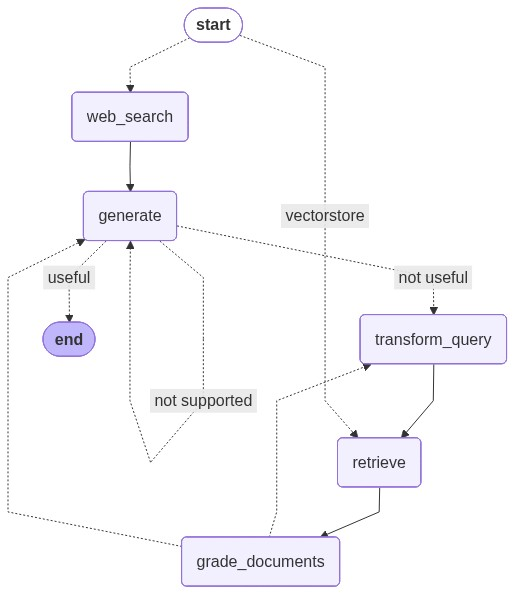

In [78]:
# Visualise the graph (requires graphviz)
from IPython.display import Image, display

try:
    display(Image(adaptive_rag_app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualisation skipped: {e}")

## 6. Run & Test

Stream the graph for a question and print the final answer.

In [79]:
from pprint import pprint

def ask(question: str) -> str:
    """Run the adaptive RAG pipeline and return the final answer."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)

    final_output = None
    for output in adaptive_rag_app.stream({"question": question}):
        for node_name, node_value in output.items():
            print(f"  [Node: {node_name}]")
            final_output = node_value

    answer = final_output.get("generation", "No answer generated.")
    print(f"\nFinal Answer:\n{answer}")
    return answer

# ── Test queries ──────────────────────────────────────────────────────────────
_ = ask("What are the symptoms and treatment of Type 2 Diabetes?")


Question: What are the symptoms and treatment of Type 2 Diabetes?
---ROUTING QUESTION---
  → Vectorstore
---RETRIEVE FROM PINECONE---
  [Node: retrieve]
---GRADING DOCUMENT RELEVANCE---
  [+] Relevant
  [-] Not relevant, filtered out
  [+] Relevant
---DECIDING: GENERATE OR REWRITE?---
  → Relevant docs found, generating
  [Node: grade_documents]
---GENERATE ANSWER---
  (attempt 1)
---GRADING GENERATION---
  → Hallucination detected (attempt 1), regenerating
  [Node: generate]
---GENERATE ANSWER---
  (attempt 2)
---GRADING GENERATION---
  → Max retries (2) reached, returning best answer
  [Node: generate]

Final Answer:
Type 2 diabetes is usually marked by insulin resistance and often has no obvious symptoms because the pancreas can initially increase insulin secretion. When treatment is needed, lifestyle changes such as diet and regular exercise are first‑line, and drug therapy (e.g., sulfonylureas like glipizide or chlorpropamide) may be added. These medications help lower blood gluc

In [80]:
_ = ask("What is Acromegaly and gigantism?")


Question: What is Acromegaly and gigantism?
---ROUTING QUESTION---
  → Vectorstore
---RETRIEVE FROM PINECONE---
  [Node: retrieve]
---GRADING DOCUMENT RELEVANCE---
  [+] Relevant
  [+] Relevant
  [+] Relevant
---DECIDING: GENERATE OR REWRITE?---
  → Relevant docs found, generating
  [Node: grade_documents]
---GENERATE ANSWER---
  (attempt 1)
---GRADING GENERATION---
  → Useful answer ✅
  [Node: generate]

Final Answer:
Acromegaly is a rare disorder caused by excess growth‑hormone release from the pituitary after bone growth has stopped, producing enlarged bones and soft tissues. Gigantism results from the same hormone excess occurring before the epiphyseal plates close, leading to abnormal linear growth and extreme height. Both conditions stem from pituitary‑derived growth‑hormone overproduction.


In [82]:
# Test web search fallback — out-of-scope/recent topic
_ = ask("top news today?")


Question: top news today?
---ROUTING QUESTION---
  → Web search
---WEB SEARCH FALLBACK---
  [Node: web_search]
---GENERATE ANSWER---
  (attempt 1)
---GRADING GENERATION---
  → Useful answer ✅
  [Node: generate]

Final Answer:
The leading story today is a Palantir executive warning of an “undeclared emergency,” discussing Iran, new U.S. weapons and how to avoid a potential World III. Other major headlines cover tensions in the Strait of Hormuz and a court move to block Trump‑era tariffs. NASA’s Artemis II mission also made news as astronauts returned safely after a lunar flyby.
